In [1]:
import os 
import sys
import re 
import cv2  
import tqdm 
import logging
import json
import glob
import tqdm
import pickle as pkl  

# wd = r'C:\Users\ADMIN\Documents\SAM\Research'
# os.chdir(wd)

import torch 
import numpy as np 
import torch.nn as nn 
import torchvision 
import fiftyone as fo
import fiftyone.zoo as foz 
import fiftyone.types as fot
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import torch.nn.functional as F 

from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from typing import List, Any 
from utils.dataLoader import COCOLoader, VOCPascalLoader, ADE20KLoader 
from utils.modelLoader import SAM1, FastSAMModel, MobileSAM
from utils.metrics import Metrics 
from ultralytics import FastSAM
from ultralytics.models.fastsam import FastSAMPredictor


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
    )



c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mobile_sam\modeling\tiny_vit_sam.py:656

## **Data Initialization**  

In [2]:
coco_datapath = r'C:\\Users\\ADMIN\\fiftyone\\coco-2017\\validation\\data'
coco_labelpath = r'C:\Users\ADMIN\fiftyone\coco-2017\raw\instances_val2017.json' 
coco_dataset = COCOLoader(coco_datapath=coco_datapath, coco_labelpath=coco_labelpath) 


 100% |███████████████| 5000/5000 [1.7m elapsed, 0s remaining, 61.8 samples/s]      


2026-04-02 09:26:50,683 - INFO -  100% |███████████████| 5000/5000 [1.7m elapsed, 0s remaining, 61.8 samples/s]      
2026-04-02 09:26:50,760 - INFO - COCOLoader | images found: 4952


In [3]:
sample = coco_dataset[15] 
sample

{'image_id': '69cdd38700a7575d90a83285',
 'image': array([[[208, 211, 246],
         [208, 211, 246],
         [207, 210, 245],
         ...,
         [  7,   9,   8],
         [  9,  11,  10],
         [ 10,  12,  11]],
 
        [[239, 245, 241],
         [239, 245, 241],
         [238, 244, 240],
         ...,
         [  6,   8,   7],
         [  6,   8,   7],
         [  7,   9,   8]],
 
        [[254, 255, 253],
         [254, 255, 253],
         [254, 255, 253],
         ...,
         [  7,   9,   8],
         [  7,   9,   8],
         [ 11,  13,  12]],
 
        ...,
 
        [[ 82,  85,  74],
         [ 79,  82,  71],
         [ 75,  78,  67],
         ...,
         [  5,   7,   6],
         [  8,  10,   9],
         [  6,   8,   7]],
 
        [[ 89,  92,  83],
         [ 88,  91,  82],
         [ 85,  88,  79],
         ...,
         [  4,   6,   5],
         [  8,  10,   9],
         [  6,   8,   7]],
 
        [[ 94,  97,  88],
         [ 93,  96,  87],
         [ 91,  94

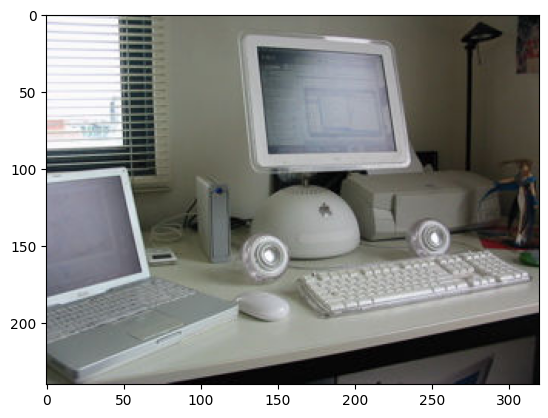

In [4]:
image = sample['image'] 
plt.imshow(image)

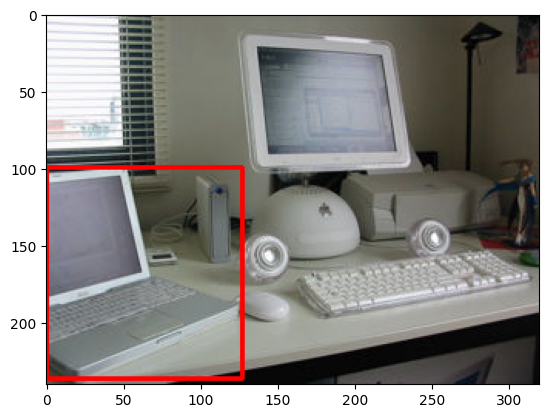

In [5]:
temporary_img = image 
bbox = sample['bounding_boxes'][0]
x_min, y_min, x_max, y_max = bbox 
cv2.rectangle(temporary_img, (x_min, y_min), (x_max, y_max), color=(255, 0, 0), thickness=2) 
plt.imshow(temporary_img)

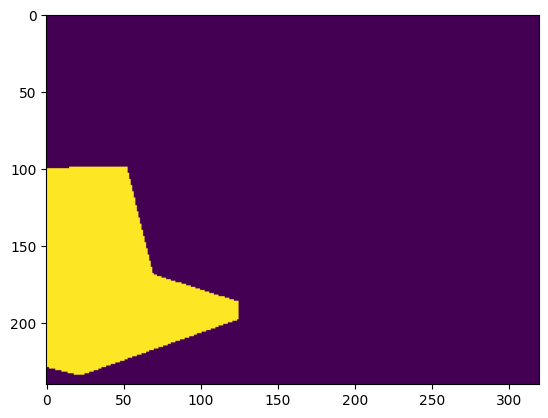

In [6]:
gt_mask = sample['masks'][0] 
plt.imshow(gt_mask)

## **Model Initialization**

##  **Multi objects segmentaion**

In [7]:
# overrides = dict(conf=0.4, task='segment', mode='predict', model='FastSAM-s.pt', save=False, imgsz=1024, retina_masks=True) 
# predictor = FastSAMPredictor(overrides=overrides) 
# everything_results = predictor(image) 


In [8]:
fast_sam_model = FastSAMModel(model_name='FastSAM', model=r'Research\model\FastSAM-x.pt')

In [12]:
mobileSAM_model = MobileSAM(model_name='MobileSAM', model_type='vit_t', checkpoint=r'C:\Users\ADMIN\Documents\SAM\Research\model\mobile_sam.pt')

In [13]:
total_IoU = [] 
total_Dice = [] 
metrics = Metrics()
sample_bounding_boxes = sample['bounding_boxes']
sample_masks = sample['masks']
fast_sam_model._set_image(image=image)
sample_IoU = []
sample_Dice = []

for bbox, gt_masks in zip(sample_bounding_boxes, sample_masks): 
    input_bbox = np.array(bbox) 
    # bbox_results = predictor.prompt(results=everything_results, bboxes=input_bbox) 
    # bbox_results = bbox_results[0] 
    # pred_mask = bbox_results.masks.data.numpy()
    pred_mask = fast_sam_model._predict(bounding_box=input_bbox)
    iou = metrics._calculate_IoU(groundtruth_mask=gt_masks, predicted_mask=pred_mask) 
    dice = metrics._calculate_Dice(groundtruth_mask=gt_masks, predicted_mask=pred_mask)
    sample_IoU.append(iou)
    sample_Dice.append(dice) 

mean_sample_iou = np.mean(sample_IoU) 
mean_sample_dice = np.mean(sample_Dice)
    # logging.info(f'mean sample IoU: {mean_sample_iou} | mean sample Dice: {mean_sample_dice}')  



logging.info(f'COCO mean IoU: {mean_sample_iou} | COCO mean Dice: {mean_sample_dice}')


Ultralytics 8.4.31  Python-3.13.7 torch-2.10.0+cpu CPU (13th Gen Intel Core i5-13420H)
YOLOv8x-seg summary (fused): 125 layers, 72,203,813 parameters, 0 gradients, 330.1 GFLOPs
0: 1024x1024 25 objects, 3545.5ms
Speed: 44.4ms preprocess, 3545.5ms inference, 49.6ms postprocess per image at shape (1, 3, 1024, 1024)


2026-04-02 09:31:50,155 - INFO - COCO mean IoU: 73.37462598879276 | COCO mean Dice: 41.72947557386048


In [14]:
mobileSAM_total_IoU = [] 
mobileSAM_total_DICE = [] 
sample_bounding_boxes = sample['bounding_boxes']
sample_masks = sample['masks']
mobileSAM_model._set_image(image=image) 
sample_IoU = []
sample_Dice = []

for bbox, gt_masks in zip(sample_bounding_boxes, sample_masks): 
    input_bbox = np.array(bbox) 
    # bbox_results = predictor.prompt(results=everything_results, bboxes=input_bbox) 
    # bbox_results = bbox_results[0] 
    # pred_mask = bbox_results.masks.data.numpy()
    masks, scores, logits = mobileSAM_model._predict(bounding_box=input_bbox)
    pred_mask = masks[0]
    iou = metrics._calculate_IoU(groundtruth_mask=gt_masks, predicted_mask=pred_mask) 
    dice = metrics._calculate_Dice(groundtruth_mask=gt_masks, predicted_mask=pred_mask)
    sample_IoU.append(iou)
    sample_Dice.append(dice) 
mean_sample_iou = np.mean(sample_IoU) 
mean_sample_dice = np.mean(sample_Dice)
logging.info(f'COCO mean IoU: {mean_sample_iou} | COCO mean Dice: {mean_sample_dice}')

2026-04-02 09:35:32,938 - INFO - COCO mean IoU: 77.81668251079931 | COCO mean Dice: 43.534316402073806
